In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

from model_utils import (
    plot_confusion_matrix,
    get_top_features_multiclass,
    display_top_features,
    test_phishing_examples,
    save_model,
    print_model_summary
)

In [2]:
# Set random seed for reproducibility
RANDOM_STATE = 42

## Load and Explore the Phishing Dataset

In [3]:
df = pd.read_csv('../data/phishing_legit_dataset_cleaned.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (10000, 5)

Column names: ['text', 'label', 'phishing_type', 'severity', 'confidence']

First few rows:


,text,label,phishing_type,severity,confidence
0,Thanks for your help on the analysis. I've pus...,0,legitimate,low,0.95
1,"Hello, your profile has been locked. Use the s...",1,credential_harvesting,high,0.89
2,"Hi there, congratulations! You are the winner ...",1,financial_scam,medium,0.69
3,"Attention, this is the fraud prevention accoun...",1,authority_scam,high,0.91
4,"Notice, your profile has been restricted. Use ...",1,credential_harvesting,high,0.80


In [4]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Drop rows with missing text
df = df.dropna(subset=['text', 'phishing_type'])
print(f"\nShape after dropping NaN: {df.shape}")

Missing values:
text             0
label            0
phishing_type    0
severity         0
confidence       0
dtype: int64

Shape after dropping NaN: (10000, 5)


Phishing Type Distribution:
phishing_type
legitimate                     4000
credential_harvesting          1000
urgency                        1000
financial_scam                  500
authority_scam                  500
romance_dating                  500
generic_phishing                500
threats                         500
tech_support                    500
social_engineering_advanced     500
social_engineering              500
Name: count, dtype: int64


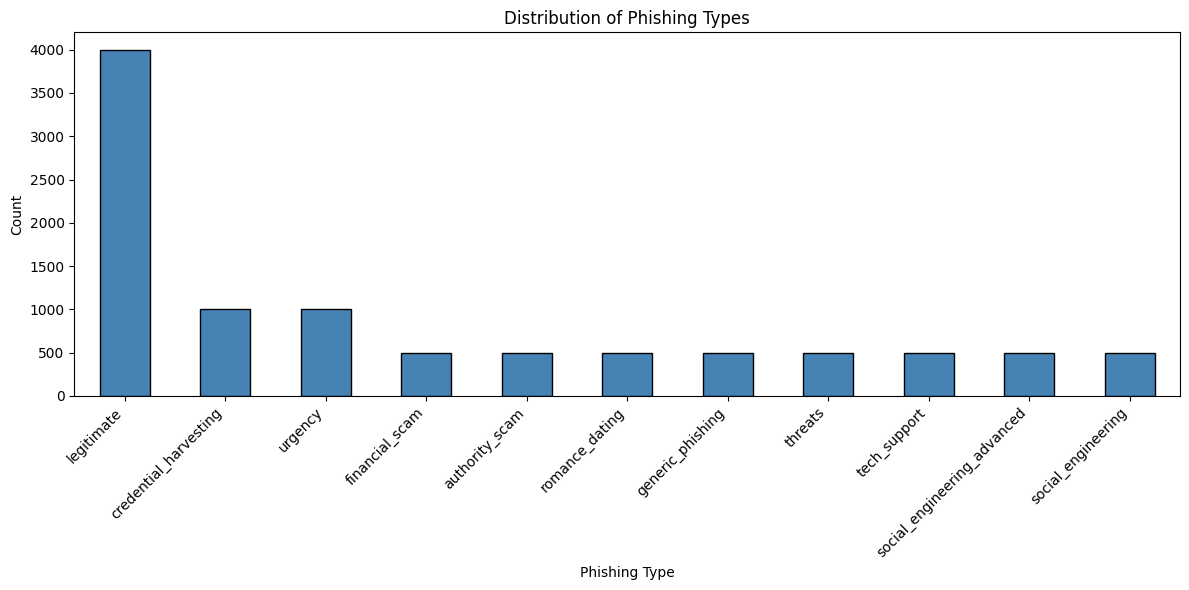

In [5]:
# Examine the distribution of phishing types (our target variable)
print("Phishing Type Distribution:")
print(df['phishing_type'].value_counts())

# Visualize class distribution
plt.figure(figsize=(12, 6))
df['phishing_type'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribution of Phishing Types')
plt.xlabel('Phishing Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Prepare Features and Target

In [6]:
# Use 'text' column as features and 'phishing_type' as target (multi-class)
X = df['text']
y = df['phishing_type']

print(f"Number of samples: {len(X)}")
print(f"Number of classes: {y.nunique()}")
print(f"Classes: {y.unique().tolist()}")

Number of samples: 10000
Number of classes: 11
Classes: ['legitimate', 'credential_harvesting', 'financial_scam', 'authority_scam', 'urgency', 'romance_dating', 'generic_phishing', 'threats', 'tech_support', 'social_engineering_advanced', 'social_engineering']


## Train/Test Split with Stratification

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y # Maintain class distribution in splits
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

print(f"\nTraining set class distribution:")
print(y_train.value_counts())

Training set size: 8000
Test set size: 2000

Training set class distribution:
phishing_type
legitimate                     3200
urgency                         800
credential_harvesting           800
financial_scam                  400
romance_dating                  400
threats                         400
authority_scam                  400
social_engineering              400
tech_support                    400
social_engineering_advanced     400
generic_phishing                400
Name: count, dtype: int64


## TF-IDF Vectorization

In [8]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),  # Use unigrams and bigrams
    min_df=2,            # Ignore terms that appear in fewer than 2 documents
    stop_words='english' # Remove common English stop words
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Training set shape: {X_train_vec.shape}")
print(f"Test set shape: {X_test_vec.shape}")
print(f"Vocabulary size: {len(vectorizer.get_feature_names_out())}")

Training set shape: (8000, 1491)
Test set shape: (2000, 1491)
Vocabulary size: 1491


## Train Naive Bayes Classifier

In [9]:
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train_vec, y_train)

print(f"Classes: {nb_classifier.classes_}")

Classes: ['authority_scam' 'credential_harvesting' 'financial_scam'
 'generic_phishing' 'legitimate' 'romance_dating' 'social_engineering'
 'social_engineering_advanced' 'tech_support' 'threats' 'urgency']


In [10]:
# Predict on training set
y_train_pred = nb_classifier.predict(X_train_vec)

# Predict on test set
y_test_pred = nb_classifier.predict(X_test_vec)

## Evaluate Model Performance

In [11]:
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Training Accuracy: 1.0000
Test Accuracy: 1.0000


In [12]:
print("Classification Report - Training Set\n")
print(classification_report(y_train, y_train_pred))

print("Classification Report - Test Set\n")
print(classification_report(y_test, y_test_pred))

Classification Report - Training Set

                             precision    recall  f1-score   support

             authority_scam       1.00      1.00      1.00       400
      credential_harvesting       1.00      1.00      1.00       800
             financial_scam       1.00      1.00      1.00       400
           generic_phishing       1.00      1.00      1.00       400
                 legitimate       1.00      1.00      1.00      3200
             romance_dating       1.00      1.00      1.00       400
         social_engineering       1.00      1.00      1.00       400
social_engineering_advanced       1.00      1.00      1.00       400
               tech_support       1.00      1.00      1.00       400
                    threats       1.00      1.00      1.00       400
                    urgency       1.00      1.00      1.00       800

                   accuracy                           1.00      8000
                  macro avg       1.00      1.00      1.00     

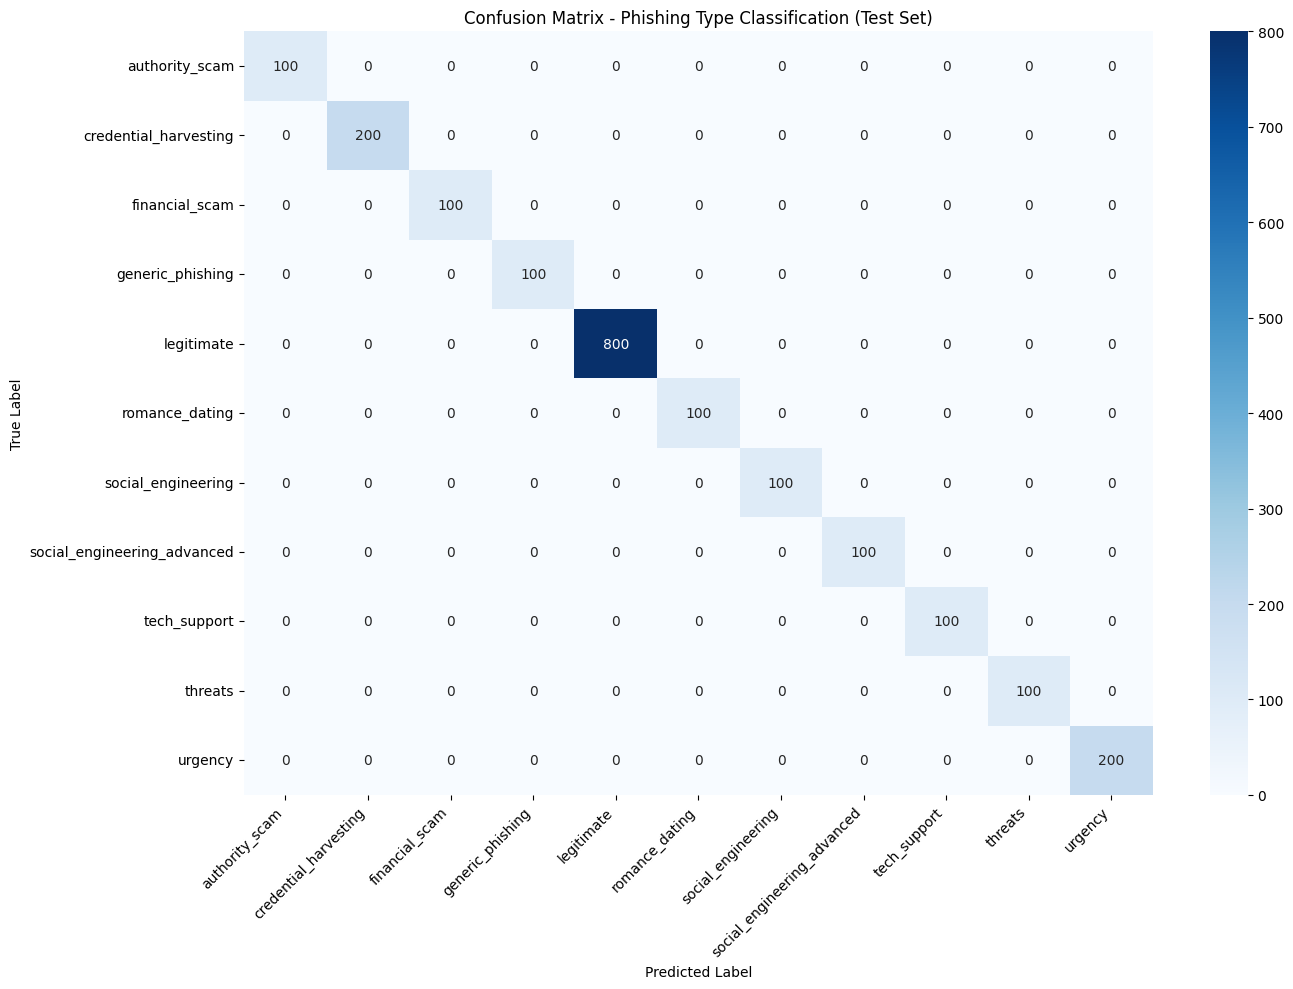

In [13]:
# Confusion Matrix - Test Set
plot_confusion_matrix(
    y_test, y_test_pred, 
    class_names=nb_classifier.classes_,
    title='Confusion Matrix - Phishing Type Classification (Test Set)'
)

## Top Features for Each Phishing Type

In [14]:
top_features = get_top_features_multiclass(vectorizer, nb_classifier, n=10)
display_top_features(top_features, n=10)

Top 10 Features for 'authority_scam':
 1. account                   (weight: -4.1861)
 2. standing follow           (weight: -4.3306)
 3. remain good               (weight: -4.3306)
 4. account today             (weight: -4.3306)
 5. today failure             (weight: -4.3306)
 6. review account            (weight: -4.3306)
 7. result                    (weight: -4.3306)
 8. respond result            (weight: -4.3306)
 9. account remain            (weight: -4.3306)
10. remain                    (weight: -4.3306)

Top 10 Features for 'credential_harvesting':
 1. password                  (weight: -3.9938)
 2. enter                     (weight: -4.0234)
 3. verification              (weight: -4.0266)
 4. restore access            (weight: -4.0779)
 5. restore                   (weight: -4.0779)
 6. username                  (weight: -4.1253)
 7. code                      (weight: -4.1431)
 8. 2fa                       (weight: -4.2870)
 9. enter username            (weight: -4.3019)
10. 

## Test on New Samples

In [15]:
test_examples = [
    "Hi, can you send me the quarterly report by end of day? Thanks!",
    "URGENT: Your account has been compromised! Click here to verify your password immediately or your account will be suspended.",
    "Congratulations! You've won $1,000,000! Send us your bank details to claim your prize.",
    "This is the IRS. You owe back taxes. Call this number immediately to avoid arrest.",
    "I saw your profile and felt a connection. I'm looking for someone special. Can we chat privately?",
    "Your computer has been infected with a virus! Call Microsoft support now at this number to fix it."
]

test_phishing_examples(test_examples, vectorizer, nb_classifier)

Phishing Type Predictions:

Example 1:
Text: Hi, can you send me the quarterly report by end of day? Thanks!
Prediction: legitimate (Confidence: 96.83%)
Top 3 predictions:
  - legitimate: 96.83%
  - credential_harvesting: 0.43%
  - social_engineering: 0.37%

Example 2:
Text: URGENT: Your account has been compromised! Click here to verify your password immediately or your ac...
Prediction: credential_harvesting (Confidence: 70.71%)
Top 3 predictions:
  - credential_harvesting: 70.71%
  - urgency: 16.90%
  - social_engineering: 4.71%

Example 3:
Text: Congratulations! You've won $1,000,000! Send us your bank details to claim your prize.
Prediction: financial_scam (Confidence: 94.78%)
Top 3 predictions:
  - financial_scam: 94.78%
  - authority_scam: 0.96%
  - legitimate: 0.73%

Example 4:
Text: This is the IRS. You owe back taxes. Call this number immediately to avoid arrest.
Prediction: urgency (Confidence: 46.51%)
Top 3 predictions:
  - urgency: 46.51%
  - financial_scam: 16.67%
  - thr

## Save Model and Vectorizer

In [16]:
save_model(nb_classifier, vectorizer, 'phishing_nb', models_dir='../models')

Model saved to ../models\phishing_nb_model.joblib
Vectorizer saved to ../models\phishing_nb_vectorizer.joblib


('../models\\phishing_nb_model.joblib',
 '../models\\phishing_nb_vectorizer.joblib')

In [17]:
print_model_summary(
    model_name="Naive Bayes",
    df=df,
    y=y,
    X_train=X_train,
    X_test=X_test,
    train_accuracy=train_accuracy,
    test_accuracy=test_accuracy
)

PHISHING TYPE CLASSIFICATION - NAIVE BAYES SUMMARY

Total samples: 10000
Number of classes: 11
Training samples: 8000
Test samples: 2000

Training Accuracy: 1.0000
Test Accuracy: 1.0000
